# Survey Overview (Sharing-Eligible Responses)

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("COUHES-approved-data - mid-term-survey.csv")
print(f"Loaded {len(df)} responses with {df.shape[1]} columns.")


Loaded 95 responses with 20 columns.


In [171]:
df.head()

,Timestamp,I have reviewed my Milestone 2 feedback.,Which feedback structure do you prefer overall for milestones?,"Compared with Milestone 1 feedback, Milestone 2 feedback was:","Did you expect a different type of early feedback for this milestone? If yes, what did you expect?",The early feedback helped me identify specific mistakes.,The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.,This process helps me meet the deliverable expectations.,I am comfortable with AI-assisted early feedback if it is human-reviewed.,I trust the challenge/appeal path when feedback seems wrong.,I clearly understood what role AI vs TAs/instructor played.,I am confident in TA final regrading fairness and consistency.,How did the submit + quick detailed feedback + resubmission cycle affect your learning process?,In what assignment scenarios would you NOT want this model (early feedback + resubmission)?,Biggest advantage for you of bringing GenAI into early feedback:,Biggest disadvantage for you of bringing GenAI into early feedback:,One concrete change you recommend for the next milestone feedback process:,What else would you like to share with the instructor and TAs on this topic?,Consent 2,Consent 3
0,2/14/2026 16:04:44,Yes,Early feedback + resubmission,About the same,No,3 - Neutral,4 - Agree,4 - Agree,3 - Neutral,3 - Neutral,4 - Agree,4 - Agree,resubmission clarify what i was right and what...,already well-understanding.,In good logic and effective,not that trustful,no,we need resubmission,I consent to my name being attached to my resp...,I’m open to a follow-up conversation; please c...
1,2/14/2026 17:20:50,Yes,Early feedback + resubmission,About the same,NaN,4 - Agree,5 - Strongly agree,5 - Strongly agree,4 - Agree,3 - Neutral,4 - Agree,4 - Agree,I think it actually helped me learn a lot beca...,I can't think of anytime I wouldn't.,It finds details that humans might not even no...,Sometimes the AI is almost looking for somethi...,Just making the feedback comment a bit more re...,NaN,NaN,NaN
2,2/14/2026 17:41:50,Yes,Hybrid/other approach,More useful,Maybe comment on the pdf so it might be more c...,4 - Agree,3 - Neutral,4 - Agree,4 - Agree,4 - Agree,3 - Neutral,4 - Agree,The submit + quick feedback + resubmission cyc...,If the workload is heavy and the assignment an...,The biggest advantage is getting fast feedback...,It might could feel overwhelming if there are ...,"Maybe make the AI feedback a bit more focused,...",NaN,I consent to my name being attached to my resp...,I’m open to a follow-up conversation; please c...
3,2/15/2026 15:35:05,Yes,Early feedback + resubmission,More useful,NaN,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,3 - Neutral,4 - Agree,4 - Agree,5 - Strongly agree,The submit + quick feedback + resubmission cyc...,During the test?,The biggest advantage for me is getting immedi...,One possible disadvantage is that it can make ...,I would recommend is providing a short summary...,NaN,I consent to my name being attached to my resp...,NaN
4,2/16/2026 12:20:02,Yes,Early feedback + resubmission,About the same,NaN,4 - Agree,4 - Agree,4 - Agree,2 - Disagree,4 - Agree,3 - Neutral,3 - Neutral,"Through the submit, quick detailed feedback, a...",I would not want the model of early feedback a...,"Perhaps speed of grading, as GenAI may be able...","Potential for error, specifically through pote...",Being more specific when pointing out areas wh...,NaN,NaN,NaN


In [172]:
# Locate consent column and build consent flags
consent_opts = {
    "consent": "Timestamp",
    "named_use": "Consent 2",
    "follow_up": "Consent 3"
}

for k, col_name in consent_opts.items():
    df[k] = ~df[col_name].isna()

df_share = df.copy()
print(f"Responses agreeing to share beyond class: {len(df_share)} / {len(df)}")
print("Consent option counts (all responses):")
print(df[["consent", "named_use", "follow_up"]].sum().sort_values(ascending=False))

Responses agreeing to share beyond class: 95 / 95
Consent option counts (all responses):
consent      95
follow_up    24
named_use    22
dtype: int64


In [173]:
# Plot 1: Consent option uptake across all respondents
consent_counts = df[["consent", "named_use", "follow_up"]].sum().sort_values(ascending=False)
labels = {
    "consent": "Consent",
    "named_use": "Named attribution",
    "follow_up": "Open to follow-up"
}


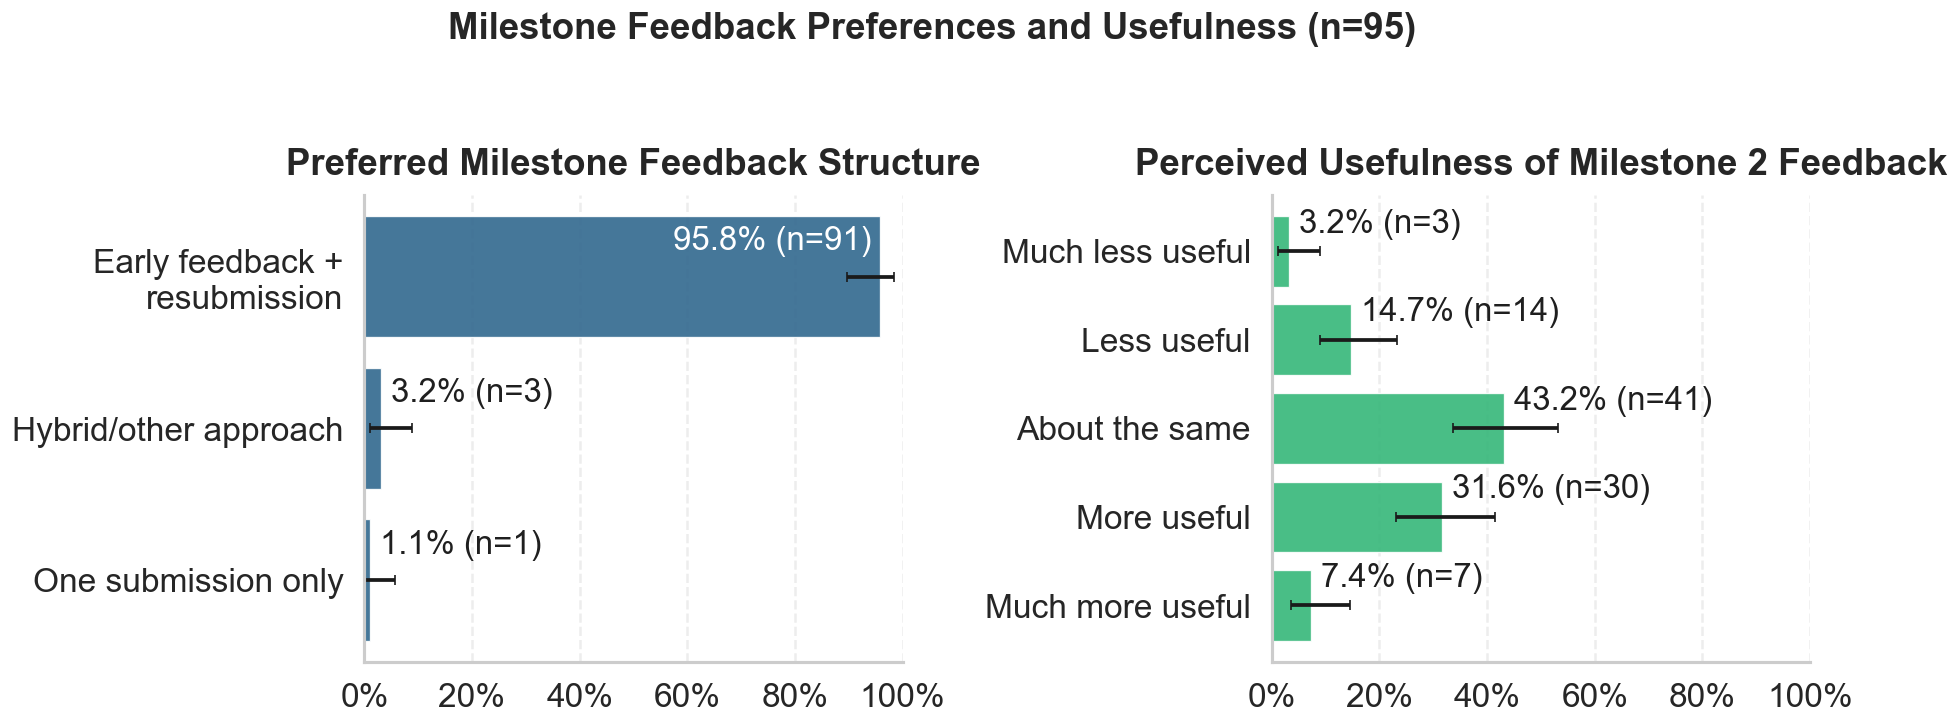

In [174]:
# Plot 2: Distribution of milestone preference and perceived usefulness (sharing-eligible only)
from textwrap import fill
from matplotlib.ticker import PercentFormatter

pref_col = "Which feedback structure do you prefer overall for milestones?"
useful_col = "Compared with Milestone 1 feedback, Milestone 2 feedback was:"


def _size(value, fallback):
    return float(value) if isinstance(value, (int, float)) else float(fallback)


def wilson_interval(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + (z ** 2) / n
    center = (p + (z ** 2) / (2 * n)) / denom
    margin = (z * np.sqrt((p * (1 - p) / n) + (z ** 2) / (4 * n ** 2))) / denom
    return max(0.0, center - margin), min(1.0, center + margin)


def summarize_proportions(series, order=None):
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    else:
        counts = counts.sort_values(ascending=False)

    n = int(counts.sum())
    rows = []
    for category, k in counts.items():
        lo, hi = wilson_interval(int(k), n)
        rows.append({
            "category": str(category),
            "count": int(k),
            "prop": k / n if n else 0.0,
            "ci_low": lo,
            "ci_high": hi,
            "n_total": n,
        })
    return pd.DataFrame(rows)


left_df = summarize_proportions(df_share[pref_col])
left_df["category"] = left_df["category"].map(lambda x: fill(x, width=26))
left_df = left_df.iloc[::-1]

usefulness_order = [
    "Much less useful",
    "Less useful",
    "About the same",
    "More useful",
    "Much more useful",
]
right_df = summarize_proportions(df_share[useful_col], order=usefulness_order)
right_df["category"] = right_df["category"].map(lambda x: fill(x, width=20))
right_df = right_df.iloc[::-1]

font_scale = 1.22
with sns.plotting_context("talk", font_scale=font_scale), sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    subplot_title_size = _size(plt.rcParams.get("axes.titlesize", 14), 14)
    axis_label_size = _size(plt.rcParams.get("axes.labelsize", 12), 12)
    tick_label_size = _size(plt.rcParams.get("xtick.labelsize", 11), 11)
    annotation_fontsize = axis_label_size * 0.9

    for ax, frame, title, color in [
        (axes[0], left_df, "Preferred Milestone Feedback Structure", "#31688E"),
        (axes[1], right_df, "Perceived Usefulness of Milestone 2 Feedback", "#35B779"),
    ]:
        xerr = np.vstack([
            frame["prop"] - frame["ci_low"],
            frame["ci_high"] - frame["prop"],
        ])

        ax.barh(
            frame["category"],
            frame["prop"],
            xerr=xerr,
            color=color,
            alpha=0.9,
            capsize=3,
            edgecolor="white",
            linewidth=0.8,
        )
        ax.set_title(title, pad=12, fontsize=subplot_title_size)
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.set_xlim(0, 1.0)
        ax.grid(axis="x", linestyle="--", alpha=0.35)
        ax.grid(axis="y", visible=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", labelsize=tick_label_size)
        ax.tick_params(axis="y", labelsize=tick_label_size)

        for y, (_, row) in enumerate(frame.iterrows()):
            high_share = row["prop"] >= 0.95
            if high_share:
                # Keep very-high-share labels inside the bar for readability.
                x_pos = max(row["prop"] - 0.015, 0.05)
                ha = "right"
                text_color = "white"
            else:
                x_pos = min(row["prop"] + 0.018, 0.985)
                ha = "left" if row["prop"] < 0.9 else "right"
                text_color = "#1f1f1f"

            y_pos = y + 0.13  # nudge labels slightly downward for cleaner alignment
            ax.text(
                x_pos,
                y_pos,
                f"{row['prop']:.1%} (n={row['count']})",
                va="bottom",
                ha=ha,
                fontsize=annotation_fontsize,
                color=text_color,
            )

    fig.suptitle(
        f"Milestone Feedback Preferences and Usefulness (n={len(df_share)})",
        y=1.03,
        fontsize=subplot_title_size,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


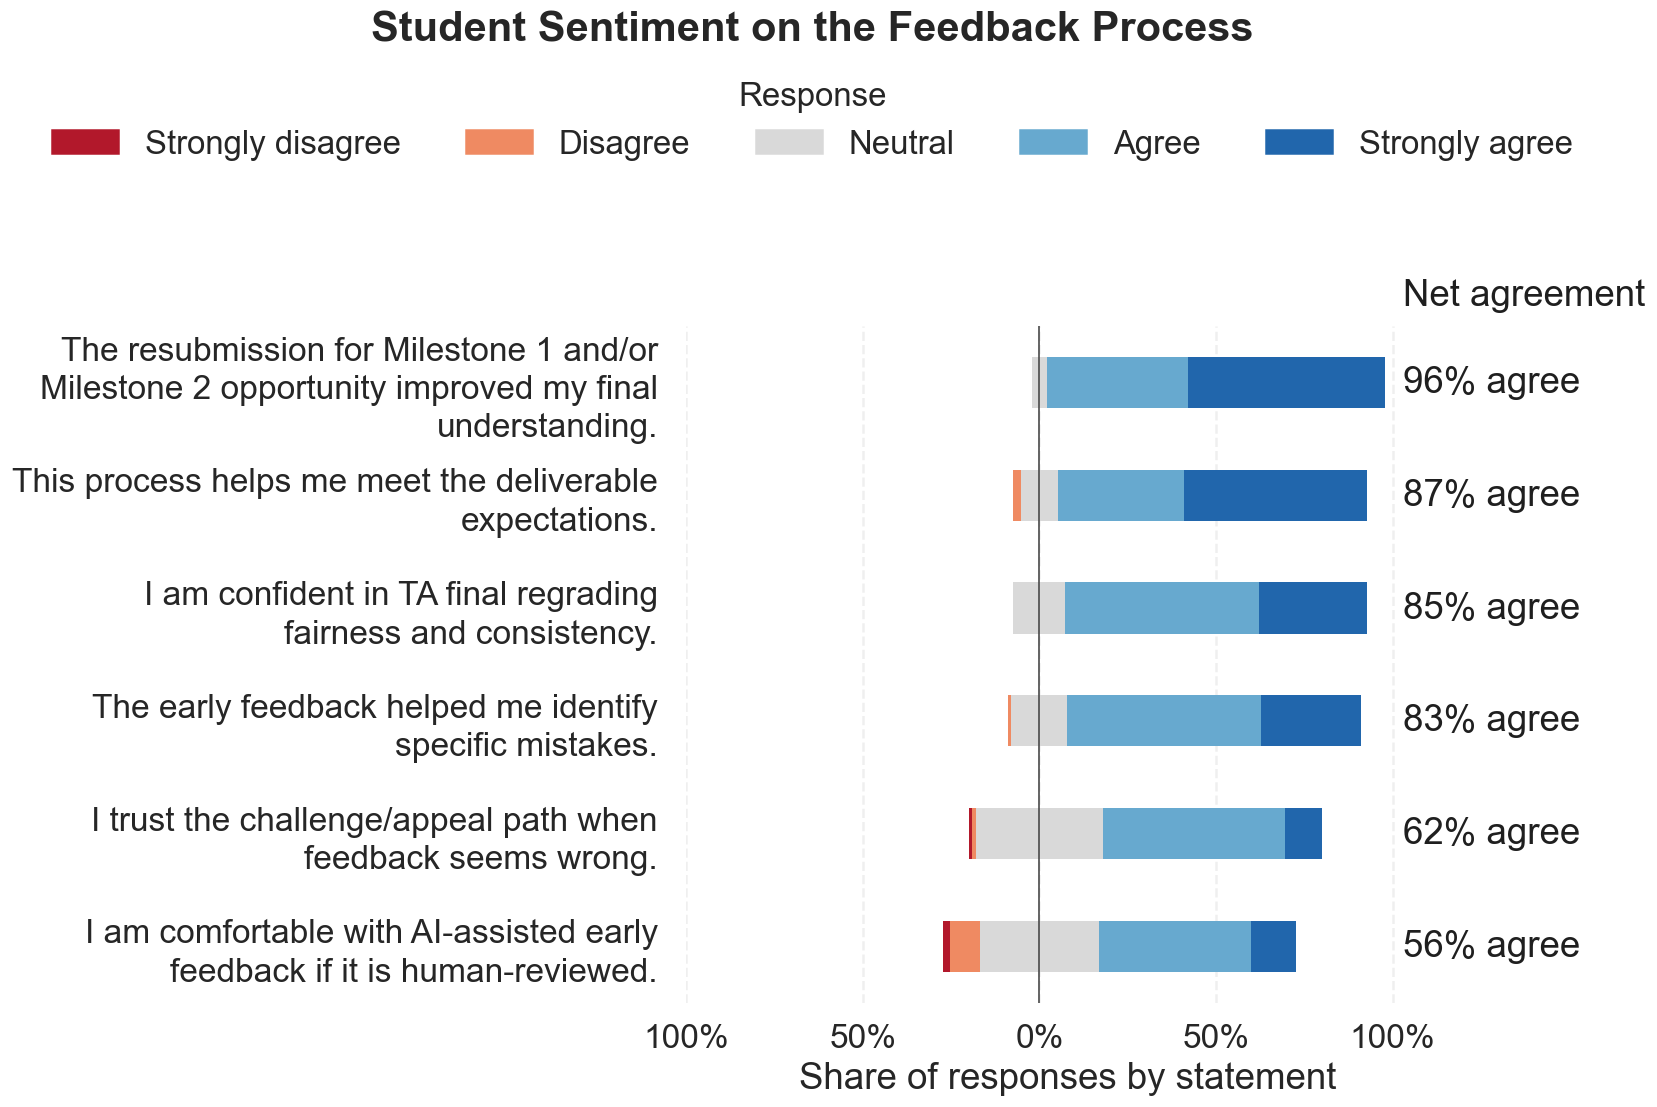

In [175]:
# Plot 3: Diverging Likert distributions for key process-confidence statements (sharing-eligible only)
from textwrap import fill
from matplotlib.ticker import FuncFormatter

likert_cols = [
    "The early feedback helped me identify specific mistakes.",
    "The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.",
    "This process helps me meet the deliverable expectations.",
    "I am comfortable with AI-assisted early feedback if it is human-reviewed.",
    "I trust the challenge/appeal path when feedback seems wrong.",
    "I am confident in TA final regrading fairness and consistency.",
]

likert_order = [
    "1 - Strongly disagree",
    "2 - Disagree",
    "3 - Neutral",
    "4 - Agree",
    "5 - Strongly agree",
]

short_order = [label.split(" - ", 1)[1] for label in likert_order]
color_map = {
    "1 - Strongly disagree": "#B2182B",
    "2 - Disagree": "#EF8A62",
    "3 - Neutral": "#D9D9D9",
    "4 - Agree": "#67A9CF",
    "5 - Strongly agree": "#2166AC",
}

# Response distribution by question
rows = []
for col in likert_cols:
    row = df_share[col].value_counts(normalize=True).reindex(likert_order).fillna(0)
    rows.append(row)

dist_df = pd.DataFrame(rows, index=likert_cols)

# Order statements by overall agreement to improve scanability
agree_share = dist_df["4 - Agree"] + dist_df["5 - Strongly agree"]
dist_df = dist_df.loc[agree_share.sort_values(ascending=False).index]

font_scale = 1.22
with sns.plotting_context("talk", font_scale=font_scale), sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 9.6))
    y_step = 1.32
    y_pos = np.arange(len(dist_df)) * y_step

    axis_label_size = plt.rcParams.get("axes.labelsize", 14)
    if isinstance(axis_label_size, str):
        axis_label_size = 14
    tick_label_size = plt.rcParams.get("xtick.labelsize", 12)
    if isinstance(tick_label_size, str):
        tick_label_size = 12

    for i, (_, row) in enumerate(dist_df.iterrows()):
        y = y_pos[i]
        sd = row["1 - Strongly disagree"]
        d = row["2 - Disagree"]
        n = row["3 - Neutral"]
        a = row["4 - Agree"]
        sa = row["5 - Strongly agree"]

        starts = {
            "1 - Strongly disagree": -(sd + d + n / 2),
            "2 - Disagree": -(d + n / 2),
            "3 - Neutral": -(n / 2),
            "4 - Agree": n / 2,
            "5 - Strongly agree": n / 2 + a,
        }

        for label in likert_order:
            ax.barh(
                y,
                row[label],
                left=starts[label],
                color=color_map[label],
                edgecolor="none",
                linewidth=0,
                height=0.60,
            )

        ax.text(
            1.03,
            y,
            f"{(a + sa):.0%} agree",
            va="center",
            ha="left",
            fontsize=axis_label_size,
            color="#1f1f1f",
        )

    ax.axvline(0, color="#4a4a4a", linewidth=1)
    ax.set_xlim(-1.0, 1.16)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.0%}"))
    ax.set_yticks(y_pos)
    ax.set_yticklabels([fill(q, width=42) for q in dist_df.index], linespacing=1.30)
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.grid(axis="y", visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.patch.set_edgecolor("none")
    ax.patch.set_linewidth(0)
    ax.tick_params(axis="x", labelsize=tick_label_size)
    ax.tick_params(axis="y", labelsize=tick_label_size, pad=8)

    fig.suptitle("Student Sentiment on the Feedback Process", y=0.975, fontsize=axis_label_size + 3, fontweight="bold")
    ax.set_xlabel("Share of responses by statement", fontsize=axis_label_size)
    ax.set_ylabel("", fontsize=axis_label_size)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color_map[label])
        for label in likert_order
    ]
    ax.text(1.03, -0.9, "Net agreement", fontsize=axis_label_size, fontweight="normal", color="#1f1f1f")

    fig.legend(
        legend_handles,
        short_order,
        title="Response",
        ncol=5,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        fontsize=axis_label_size * 0.9,
        title_fontsize=axis_label_size * 0.9,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.85])
    plt.show()


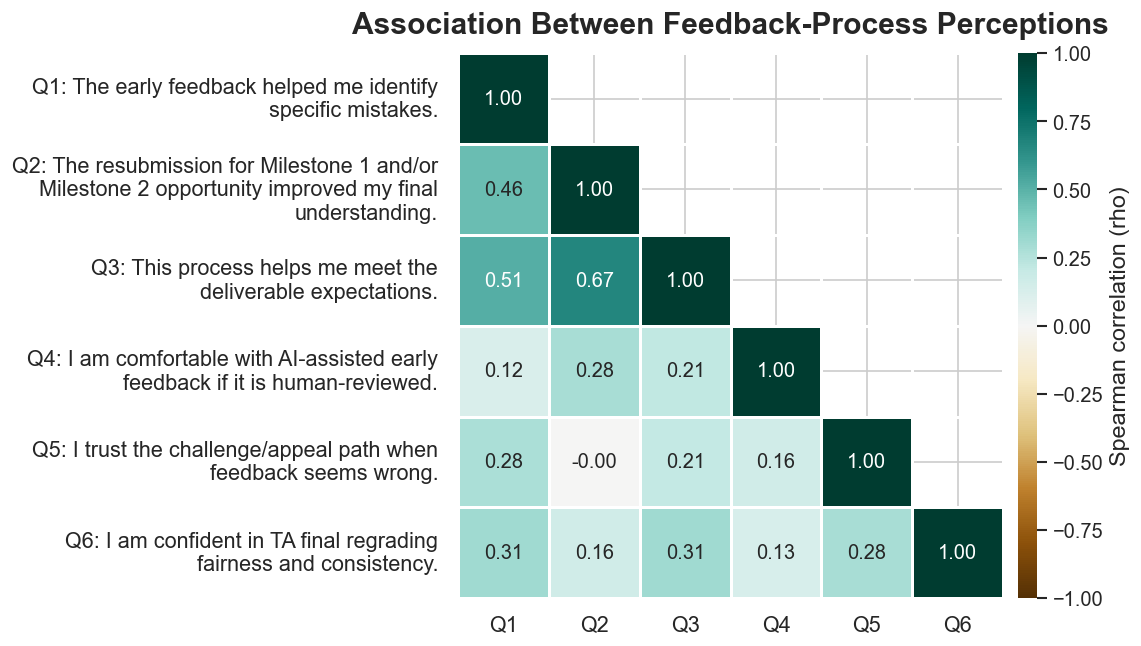

Question key:
Q1: The early feedback helped me identify specific mistakes.
Q2: The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final
understanding.
Q3: This process helps me meet the deliverable expectations.
Q4: I am comfortable with AI-assisted early feedback if it is human-reviewed.
Q5: I trust the challenge/appeal path when feedback seems wrong.
Q6: I am confident in TA final regrading fairness and consistency.


In [176]:
# Plot 4: Correlation heatmap among Likert items (sharing-eligible only)
# Ordinal Likert responses are summarized with Spearman correlations.

from textwrap import fill
from mpl_toolkits.axes_grid1 import make_axes_locatable

likert_num = df_share[likert_cols].apply(
    lambda s: pd.to_numeric(s.str.extract(r"^(\d)")[0], errors="coerce")
)
corr = likert_num.corr(method="spearman")

q_codes = [f"Q{i+1}" for i in range(len(likert_cols))]
y_labels = [fill(f"{code}: {q}", width=44) for code, q in zip(q_codes, likert_cols)]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Softer diverging scale: negative=brown, positive=green.
corr_cmap = sns.color_palette("BrBG", as_cmap=True)

fig, ax = plt.subplots(figsize=(9.2, 8.2))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3.5%", pad=0.12)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=corr_cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.7,
    linecolor="white",
    xticklabels=q_codes,
    yticklabels=y_labels,
    annot_kws={"fontsize": 12},
    cbar_ax=cax,
    cbar_kws={"label": "Spearman correlation (rho)"},
    ax=ax,
)

ax.set_title("Association Between Feedback-Process Perceptions", pad=12, fontsize=18, fontweight="bold")
ax.tick_params(axis="x", rotation=0, labelsize=13)
ax.tick_params(axis="y", rotation=0, pad=6, labelsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Spearman correlation (rho)", size=14)

plt.tight_layout()
plt.show()

print("Question key:")
for code, question in zip(q_codes, likert_cols):
    print(f"{code}: {fill(question, width=95)}")


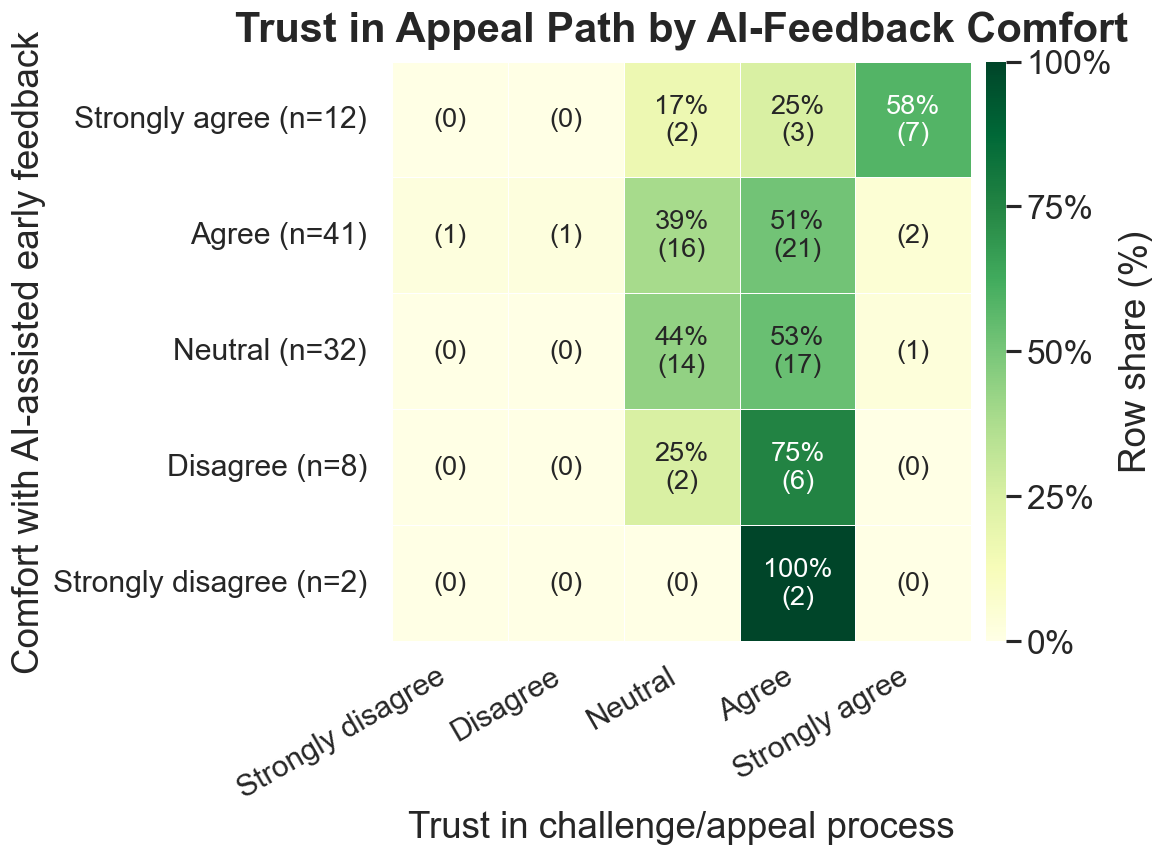

In [177]:
# Plot 5: Relationship between AI comfort and trust in challenge/appeal path
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import PercentFormatter

ai_col = "I am comfortable with AI-assisted early feedback if it is human-reviewed."
trust_col = "I trust the challenge/appeal path when feedback seems wrong."

likert_order = [
    "1 - Strongly disagree",
    "2 - Disagree",
    "3 - Neutral",
    "4 - Agree",
    "5 - Strongly agree",
]
short_labels = [label.split(" - ", 1)[1] for label in likert_order]
row_order = likert_order[::-1]  # show Strongly agree at top
row_short_labels = [label.split(" - ", 1)[1] for label in row_order]

ct_counts = pd.crosstab(df_share[ai_col], df_share[trust_col])
ct_counts = ct_counts.reindex(index=row_order, columns=likert_order, fill_value=0)
ct_row = ct_counts.div(ct_counts.sum(axis=1), axis=0).fillna(0)

row_totals = ct_counts.sum(axis=1).reindex(row_order)
y_labels = [f"{lbl} (n={int(row_totals.iloc[i])})" for i, lbl in enumerate(row_short_labels)]

annot = ct_row.copy().astype(str)
for i in range(ct_row.shape[0]):
    for j in range(ct_row.shape[1]):
        p_cell = ct_row.iat[i, j]
        n_cell = ct_counts.iat[i, j]
        if p_cell < 0.05:
            annot.iat[i, j] = f"({n_cell})"
        else:
            annot.iat[i, j] = f"{p_cell:.0%}\n({n_cell})"

font_scale = 1.22
with sns.plotting_context("talk", font_scale=font_scale), sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(10.0, 7.6))

    axis_label_size = plt.rcParams.get("axes.labelsize", 14)
    if isinstance(axis_label_size, str):
        axis_label_size = 14
    tick_label_size = plt.rcParams.get("xtick.labelsize", 12)
    if isinstance(tick_label_size, str):
        tick_label_size = 12
    tick_label_small = tick_label_size * 0.90

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.5%", pad=0.12)

    sns.heatmap(
        ct_row,
        annot=annot,
        fmt="",
        cmap="YlGn",
        vmin=0,
        vmax=1,
        linewidths=0.6,
        linecolor="white",
        square=True,
        xticklabels=short_labels,
        yticklabels=y_labels,
        annot_kws={"fontsize": tick_label_small * 0.90},
        cbar_ax=cax,
        cbar_kws={"label": "Row share (%)", "ticks": [0, 0.25, 0.5, 0.75, 1.0]},
        ax=ax,
    )

    ax.set_title("Trust in Appeal Path by AI-Feedback Comfort", pad=12, fontsize=axis_label_size + 3, fontweight="bold")
    ax.set_xlabel("Trust in challenge/appeal process", fontsize=axis_label_size)
    ax.set_ylabel("Comfort with AI-assisted early feedback", fontsize=axis_label_size)
    ax.tick_params(axis="x", rotation=30, labelsize=tick_label_small)
    ax.tick_params(axis="y", rotation=0, labelsize=tick_label_small, pad=6)
    plt.setp(ax.get_xticklabels(), ha="right")

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=tick_label_size)
    cbar.set_label("Row share (%)", size=axis_label_size)
    cbar.formatter = PercentFormatter(xmax=1, decimals=0)
    cbar.update_ticks()

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


In [9]:
# Quick numeric summary for interpretation
print("Sharing-eligible sample size:", len(df_share))
print("Top preferred structure:")
print(df_share[pref_col].value_counts().head(3))

print("Average Likert scores (1-5):")
mean_scores = likert_num.mean().sort_values(ascending=False)
for k, v in mean_scores.items():
    print(f"- {k}: {v:.2f}")

Sharing-eligible sample size: 95
Top preferred structure:
Which feedback structure do you prefer overall for milestones?
Early feedback + resubmission    91
Hybrid/other approach             3
One submission only               1
Name: count, dtype: int64
Average Likert scores (1-5):
- The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.: 4.52
- This process helps me meet the deliverable expectations.: 4.37
- I am confident in TA final regrading fairness and consistency.: 4.16
- The early feedback helped me identify specific mistakes.: 4.11
- I trust the challenge/appeal path when feedback seems wrong.: 3.69
- I am comfortable with AI-assisted early feedback if it is human-reviewed.: 3.56
